# Classical Models Comparison — Naive Bayes vs SVM vs Logistic Regression

**Master's Thesis:** Comparative Evaluation of Classical Machine Learning and Transformer-Based Models for SMS Spam Detection  
**Author:** Michał Pokracki  
**Notebook:** 03 — Classical Models Comparison

## Purpose

This notebook extends the week-2 Naive Bayes baseline into a full comparison of the three classical models that form the first half of the thesis:

- **Multinomial Naive Bayes** — the historical text-classification baseline.
- **Linear SVM** — a strong linear classifier for high-dimensional sparse TF-IDF features.
- **Logistic Regression** — a probabilistic linear baseline.

All three models share the **same preprocessing, the same train/test split, and the same evaluation code**, so any difference in results comes from the classifier itself and not from the setup. The shared logic now lives in reusable modules under `src/` (`data_loader`, `preprocessing`, `models`, `evaluation`, `train_classical`), which this notebook simply orchestrates.

> **Terminology.** The dataset labels each message as either **spam** (an unsolicited message) or **ham**. *Ham* is the standard term in the spam-filtering literature for a legitimate, non-spam message — i.e. an ordinary message the user actually wants.

## 1. Setup

In [1]:
import sys
import os

# Make the project root importable so `src` can be used from the notebook
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_sms_spam
from src.preprocessing import build_vectorizer, split_data
from src.models import get_classical_models
from src.evaluation import evaluate_model
from src.train_classical import run_comparison, _format_for_display

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RESULTS_FIG_DIR = os.path.join('..', 'results', 'figures')
os.makedirs(RESULTS_FIG_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


## 2. Run the Comparison

The `run_comparison` helper loads the data, applies the shared TF-IDF pipeline, trains all three models, and evaluates each one through the unified evaluation function.

In [2]:
results = run_comparison(save=True)
display = _format_for_display(results)

cols = ['model_name', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc',
        'train_time_s', 'inference_ms_per_msg', 'false_positives', 'false_negatives']
display[cols]

,model_name,accuracy,precision,recall,f1,roc_auc,train_time_s,inference_ms_per_msg,false_positives,false_negatives
0,Multinomial Naive Bayes,97.04,100.00,77.85,87.55,98.82,0.0024,0.0002,0,33
1,Linear SVM,98.30,95.77,91.28,93.47,98.86,0.0155,0.0001,6,13
2,Logistic Regression,97.49,89.54,91.95,90.73,98.62,0.0269,0.0001,16,12


## 3. Predictive Metrics — Side by Side

Because the dataset is imbalanced (~13% spam), accuracy alone is not enough. The chart below compares all five predictive metrics across the three models.

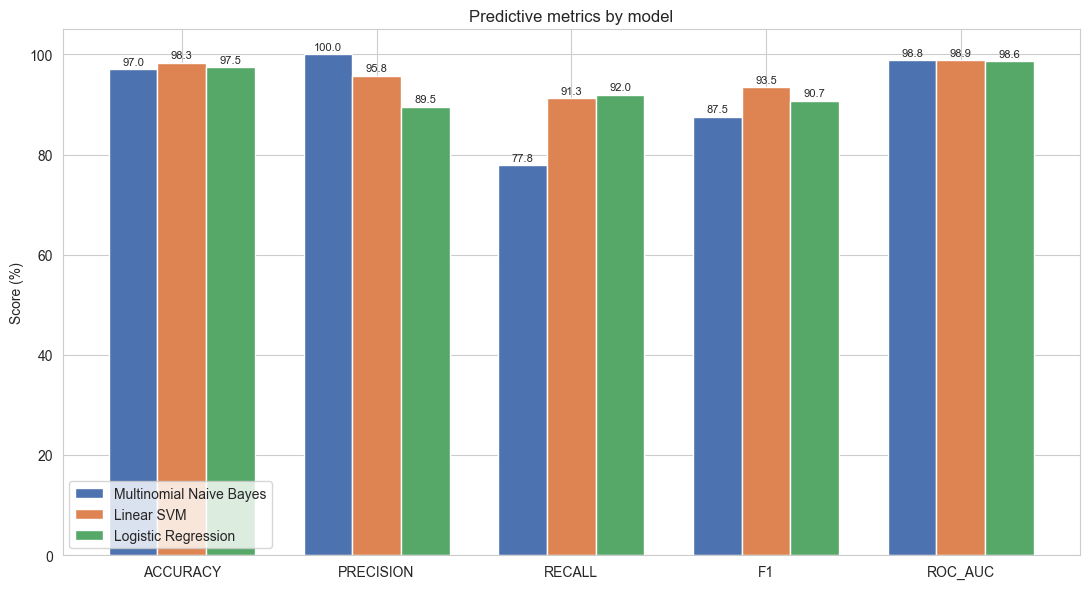

In [3]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metrics))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(11, 6))
for i, (_, row) in enumerate(display.iterrows()):
    values = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, values, width, label=row['model_name'], color=colors[i])
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f'{v:.1f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels([m.upper() for m in metrics])
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 105)
ax.set_title('Predictive metrics by model')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FIG_DIR, 'classical_metrics_comparison.png'), dpi=150)
plt.show()

## 4. Operational Cost — Training and Inference

These are the operational metrics for the classical models. They are extremely low across the board, which is exactly the point of the thesis: they establish the efficiency baseline against which DistilBERT's much higher cost will later be compared.

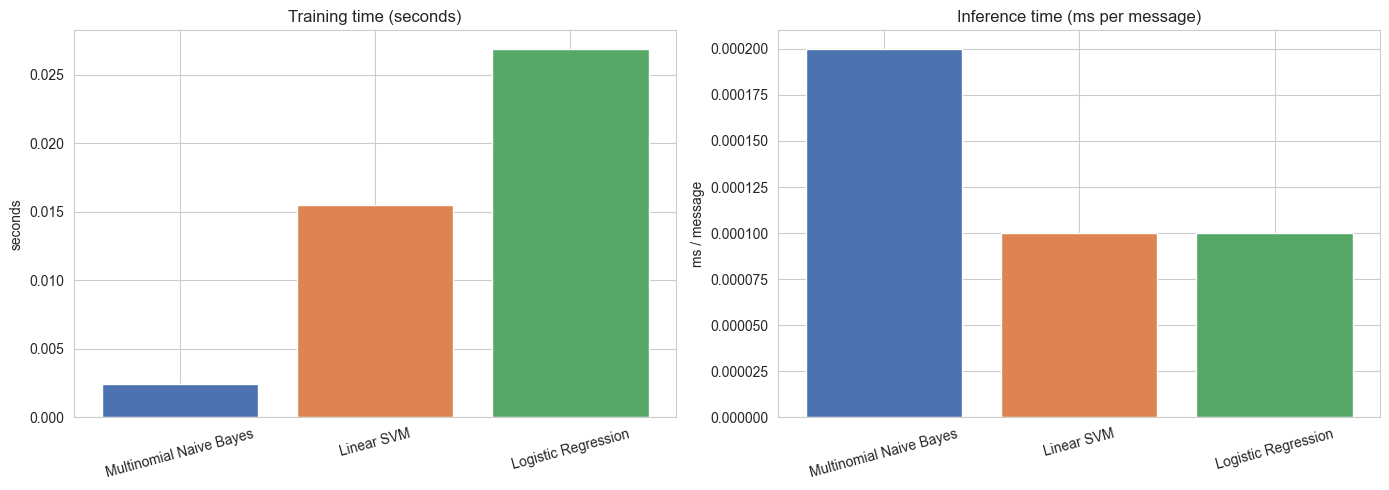

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(display['model_name'], display['train_time_s'], color=colors)
axes[0].set_title('Training time (seconds)')
axes[0].set_ylabel('seconds')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(display['model_name'], display['inference_ms_per_msg'], color=colors)
axes[1].set_title('Inference time (ms per message)')
axes[1].set_ylabel('ms / message')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FIG_DIR, 'classical_operational_comparison.png'), dpi=150)
plt.show()

## 5. Confusion Matrices

The confusion matrices show *where* each model makes mistakes — in particular the balance between false positives (ham wrongly flagged as spam, which annoys users) and false negatives (spam that slips through).

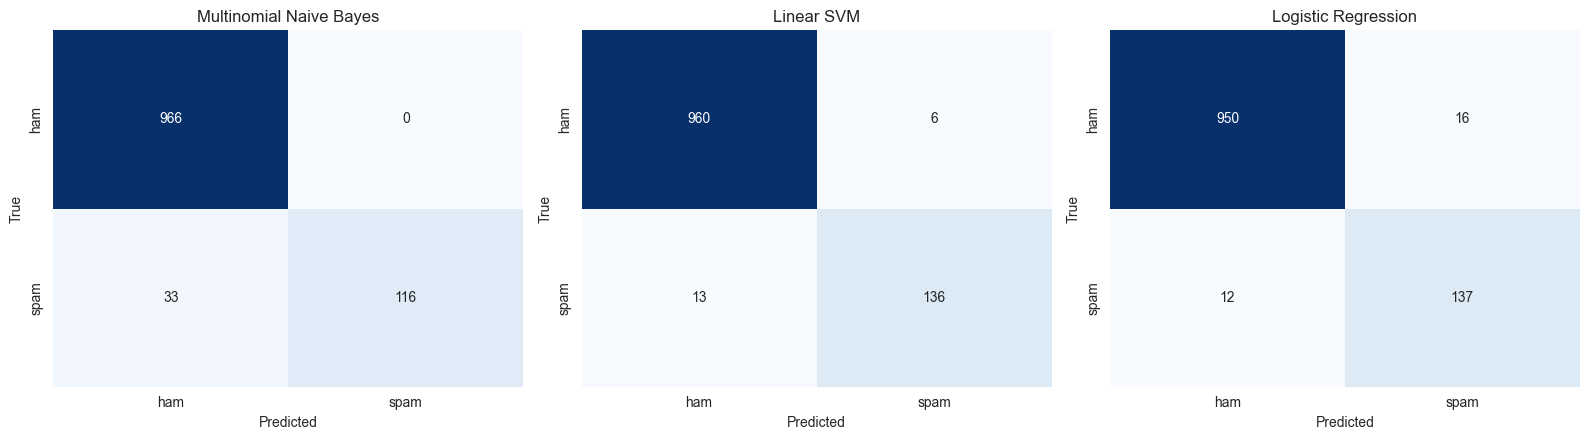

In [5]:
# Re-fit to obtain predictions for the confusion matrices
df = load_sms_spam()
X_train_raw, X_test_raw, y_train, y_test = split_data(df['message'], df['label_binary'])
vectorizer = build_vectorizer()
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, model) in zip(axes, get_classical_models().items()):
    model.fit(X_train, y_train)
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FIG_DIR, 'classical_confusion_matrices.png'), dpi=150)
plt.show()

## 6. Observations

- All three classical models reach high accuracy, but the **precision/recall balance differs**. Naive Bayes is extremely precise but misses more spam (lower recall); the two discriminative models, with `class_weight="balanced"`, trade a little precision for noticeably better recall.
- **Operational cost is negligible** for all three — training in well under a second and inference in microseconds per message. This is the efficiency reference point for the DistilBERT comparison.
- The results are produced through shared, tested modules (`src/`), and the pipeline is covered by an automated test suite (`tests/test_pipeline.py`), so the numbers are reproducible.

## Next Steps

- Fine-tune **DistilBERT** on the same split and feed its predictions through the same evaluation function.
- Add **model size** and **memory footprint** to the operational metrics (already meaningful once the transformer is in the comparison).
- Prepare the second demo around this comparison view.